In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
mv=pd.read_csv("movie_profit.csv")

In [5]:
mv.head()

,Unnamed: 0,release_date,movie,production_budget,domestic_gross,worldwide_gross,distributor,mpaa_rating,genre
0,1,6/22/2007,Evan Almighty,175000000.0,100289690.0,1.741313e+08,Universal,PG,Comedy
1,2,7/28/1995,Waterworld,175000000.0,88246220.0,2.642462e+08,Universal,PG-13,Action
2,3,5/12/2017,King Arthur: Legend of the Sword,175000000.0,39175066.0,1.399507e+08,Warner Bros.,PG-13,Adventure
3,4,12/25/2013,47 Ronin,175000000.0,38362475.0,1.517168e+08,Universal,PG-13,Action
4,5,6/22/2018,Jurassic World: Fallen Kingdom,170000000.0,416769345.0,1.304866e+09,Universal,PG-13,Action


In [11]:
mv.drop(columns=('Unnamed: 0'),inplace=True)

In [14]:
mv.columns

Index(['release_date', 'movie', 'production_budget', 'domestic_gross',
       'worldwide_gross', 'distributor', 'mpaa_rating', 'genre'],
      dtype='object')

In [16]:
mv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3401 entries, 0 to 3400
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   release_date       3401 non-null   object 
 1   movie              3401 non-null   object 
 2   production_budget  3401 non-null   float64
 3   domestic_gross     3401 non-null   float64
 4   worldwide_gross    3401 non-null   float64
 5   distributor        3353 non-null   object 
 6   mpaa_rating        3264 non-null   object 
 7   genre              3401 non-null   object 
dtypes: float64(3), object(5)
memory usage: 212.7+ KB


In [18]:
mv.isnull().sum()

release_date           0
movie                  0
production_budget      0
domestic_gross         0
worldwide_gross        0
distributor           48
mpaa_rating          137
genre                  0
dtype: int64

In [20]:
mv.describe()

,production_budget,domestic_gross,worldwide_gross
count,3.401000e+03,3.401000e+03,3.401000e+03
mean,3.328474e+07,4.542179e+07,9.411512e+07
std,3.489239e+07,5.882566e+07,1.409182e+08
min,2.500000e+05,0.000000e+00,0.000000e+00
25%,9.000000e+06,6.118683e+06,1.061881e+07
50%,2.000000e+07,2.553382e+07,4.015902e+07
75%,4.500000e+07,6.032379e+07,1.176152e+08
max,1.750000e+08,4.745447e+08,1.304866e+09


In [24]:
mv.dropna(inplace=True)

In [26]:
mv.isnull().sum()

release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
distributor          0
mpaa_rating          0
genre                0
dtype: int64

In [32]:
mv.sort_values("production_budget",ascending=True)

,release_date,movie,production_budget,domestic_gross,worldwide_gross,distributor,mpaa_rating,genre
3400,7/22/2005,November,250000.0,191862.0,191862.0,Sony Pictures Classics,R,Drama
3393,6/28/2002,Lovely and Amazing,250000.0,4210379.0,4613482.0,Lionsgate,R,Drama
3394,4/28/2017,Sleight,250000.0,3930990.0,3934450.0,High Top Releasing,R,Action
3398,3/28/1997,Love and Other Catastrophes,250000.0,212285.0,743216.0,Fox Searchlight,R,Comedy
3396,10/28/2011,Like Crazy,250000.0,3395391.0,3728400.0,Paramount Pictures,PG-13,Drama
...,...,...,...,...,...,...,...,...
9,11/10/2004,The Polar Express,170000000.0,186493587.0,310634169.0,Warner Bros.,G,Adventure
3,12/25/2013,47 Ronin,175000000.0,38362475.0,151716815.0,Universal,PG-13,Action
2,5/12/2017,King Arthur: Legend of the Sword,175000000.0,39175066.0,139950708.0,Warner Bros.,PG-13,Adventure
1,7/28/1995,Waterworld,175000000.0,88246220.0,264246220.0,Universal,PG-13,Action


In [36]:
mv["genre"].value_counts()

genre
Drama        1180
Comedy        775
Action        540
Adventure     469
Horror        266
Name: count, dtype: int64

In [38]:
mv.groupby("mpaa_rating")["domestic_gross"].mean()

mpaa_rating
G        8.253156e+07
PG       6.742011e+07
PG-13    5.487091e+07
R        3.208529e+07
Name: domestic_gross, dtype: float64

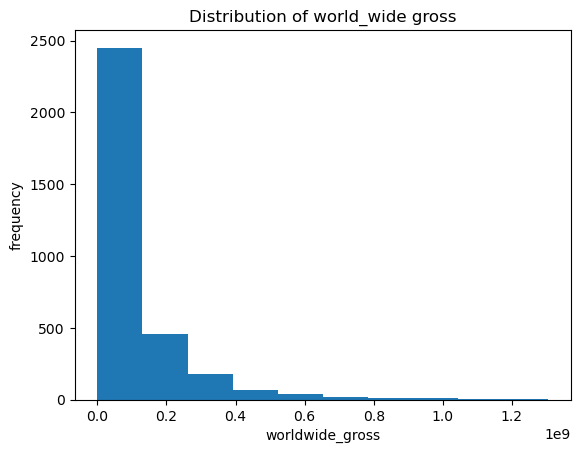

In [40]:
plt.hist(mv["worldwide_gross"])
plt.title("Distribution of world_wide gross")
plt.xlabel("worldwide_gross")
plt.ylabel("frequency")
plt.show()


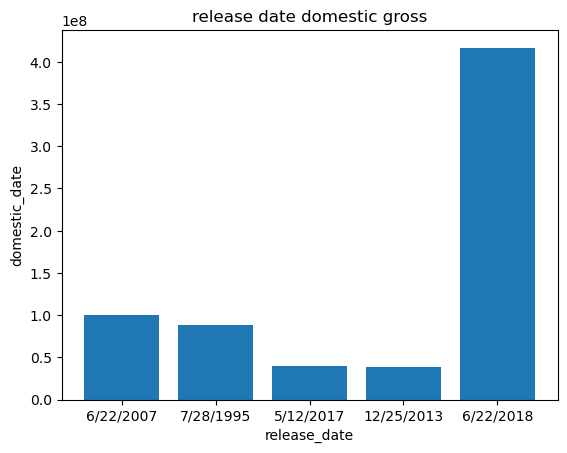

In [42]:
plt.bar(mv["release_date"].head(),mv["domestic_gross"].head())
plt.title("release date domestic gross")
plt.xlabel("release_date")
plt.ylabel("domestic_date")
plt.show()

In [54]:
mv.groupby("distributor")["worldwide_gross"].sum()

distributor
20th Century Fox        4.697384e+10
8X Entertainment        6.047691e+06
A24                     3.731241e+08
ARC Entertainment       6.745539e+06
Abramorama Films        5.491850e+05
                            ...     
Well Go USA             1.573010e+08
Wrekin Hill Enterta…    1.846613e+08
XLrator Media           9.270740e+05
Yari Film Group Rel…    8.705262e+07
Zeitgeist               6.173485e+06
Name: worldwide_gross, Length: 186, dtype: float64

In [62]:
mv.groupby("genre")["production_budget"].sum().sort_values(ascending=True)

genre
Horror       5.004500e+09
Comedy       1.950706e+10
Drama        2.641006e+10
Adventure    2.921942e+10
Action       3.159169e+10
Name: production_budget, dtype: float64

In [66]:
mv.groupby("mpaa_rating")["domestic_gross"].median()

mpaa_rating
G        58611764.5
PG       48006762.0
PG-13    34522221.0
R        15934642.0
Name: domestic_gross, dtype: float64

In [68]:
mv.groupby(mv["release_date"].str.slice(0.4))["movie"].count()

Series([], Name: movie, dtype: int64)

In [72]:
mv.groupby("mpaa_rating")["production_budget"].min()

mpaa_rating
G        560000.0
PG       300000.0
PG-13    250000.0
R        250000.0
Name: production_budget, dtype: float64

In [76]:
mv.groupby("mpaa_rating")["worldwide_gross"].var()

mpaa_rating
G        3.875780e+16
PG       3.355641e+16
PG-13    2.422744e+16
R        9.384744e+15
Name: worldwide_gross, dtype: float64

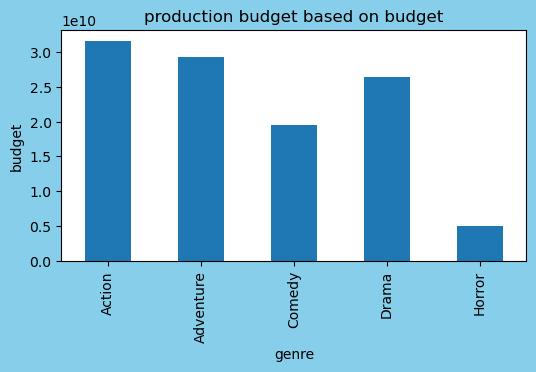

In [82]:
plt.figure(figsize=(6,3),facecolor="skyblue")
mv.groupby("genre")["production_budget"].sum().plot(kind="bar")
plt.title("production budget based on budget")
plt.xlabel("genre")
plt.ylabel("budget")
plt.show()

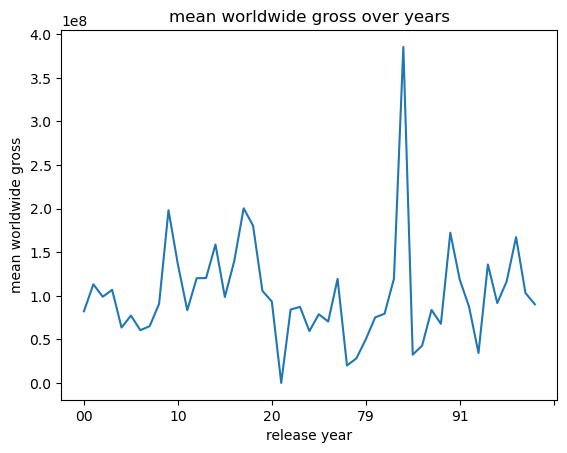

In [100]:
mv.groupby(mv["release_date"].str.slice(6,8))["worldwide_gross"].mean().plot(kind="line")
plt.title("mean worldwide gross over years")
plt.xlabel("release year")
plt.ylabel("mean worldwide gross")
plt.show()


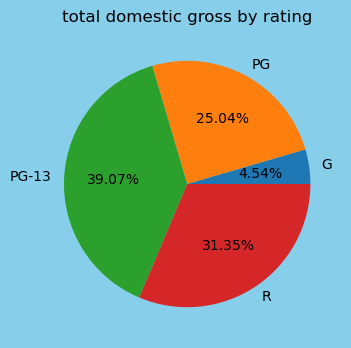

In [122]:
plt.figure(figsize=(4,4),facecolor="skyblue")
mv.groupby("mpaa_rating")["domestic_gross"].sum().plot(kind="pie",autopct="%1.2f%%")
plt.title("total domestic gross by rating")
plt.ylabel("")
plt.show()

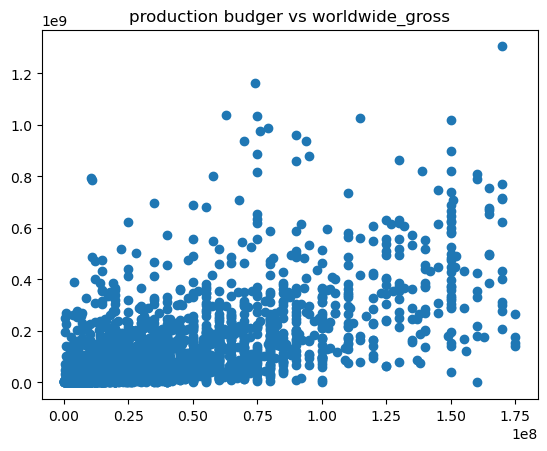

In [126]:
plt.scatter(data=mv, x="production_budget", y="worldwide_gross")
plt.title("production budger vs worldwide_gross")
plt.show()

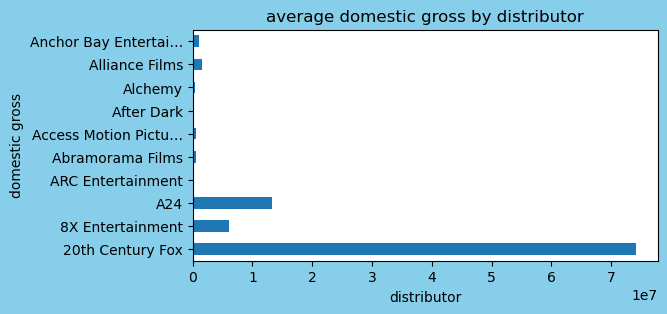

In [144]:
plt.figure(figsize=(6,3),facecolor="skyblue")
mv.groupby("distributor")["domestic_gross"].mean().head(10).plot(kind="barh")
plt.title("average domestic gross by distributor")
plt.xlabel("distributor")
plt.ylabel("domestic gross")
plt.show()